# **Inteligencia Artificial y Aprendizaje Automático**
## **Maestría en Inteligencia Artificial Aplicada**
### **Dr Luis Eduardo Falcón Morales**
### **Tecnológico de Monterrey**
## **Actividad Individual Semana 9: Pronósticos con Series de Tiempo**


#### **Nombre:**
#### **Matrícula:**

# Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense , Dropout


# Carga, limpeza y analisis de datos

In [2]:

# Cargar datos
df = pd.read_csv("D:\\Mestria\\ML\\archive\\monthly_champagne_sales.csv")
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

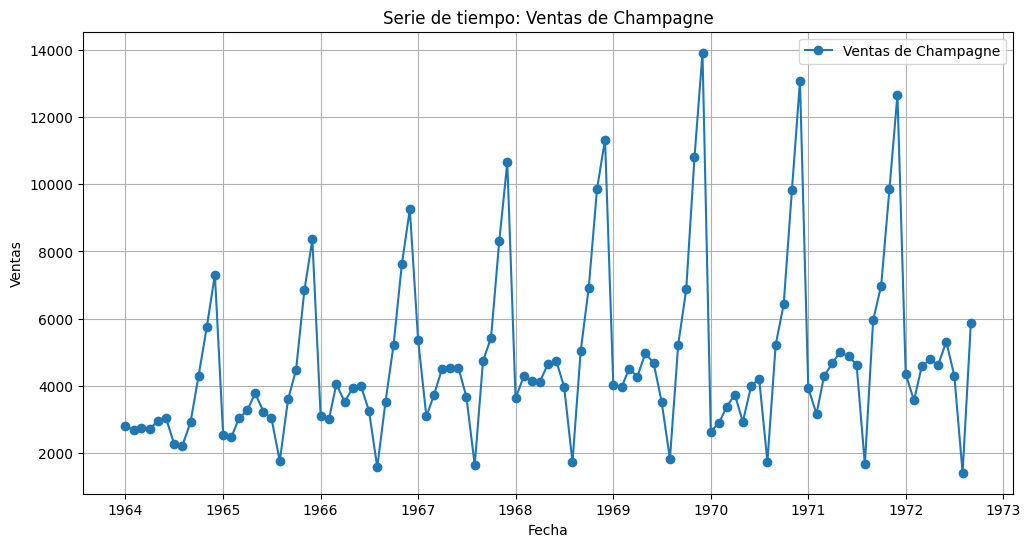

In [3]:
# Visualizar la serie de tiempo
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sales'], marker='o', linestyle='-', label="Ventas de Champagne")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.title("Serie de tiempo: Ventas de Champagne")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# Análisis exploratorio inicial
print("Resumen de datos:")
print(df.describe())
print("\nValores nulos:")
print(df.isnull().sum())


Resumen de datos:
              Sales
count    105.000000
mean    4761.152381
std     2553.502601
min     1413.000000
25%     3113.000000
50%     4217.000000
75%     5221.000000
max    13916.000000

Valores nulos:
Sales    0
dtype: int64


In [5]:
# División de datos
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Modelo Naïve


In [6]:
naive_forecast = np.full_like(test['Sales'], train['Sales'].iloc[-1])
rmse_naive = np.sqrt(mean_squared_error(test['Sales'], naive_forecast))


# Modelo ARIMA


In [7]:
model_arima = ARIMA(train['Sales'], order=(3,1,3))
fitted_arima = model_arima.fit()
arima_forecast = fitted_arima.forecast(steps=len(test))
rmse_arima = np.sqrt(mean_squared_error(test['Sales'], arima_forecast))

c:\Users\52614\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\52614\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\52614\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\52614\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# Modelo Prophet

In [8]:

train_prophet = train.reset_index().rename(columns={'Month': 'ds', 'Sales': 'y'})
test_prophet = test.reset_index().rename(columns={'Month': 'ds', 'Sales': 'y'})
model_prophet = Prophet()
model_prophet.fit(train_prophet)
future_dates = test_prophet[['ds']]
prophet_forecast = model_prophet.predict(future_dates)
prophet_pred = prophet_forecast['yhat'].values
rmse_prophet = np.sqrt(mean_squared_error(test['Sales'], prophet_pred))


14:33:05 - cmdstanpy - INFO - Chain [1] start processing
14:33:06 - cmdstanpy - INFO - Chain [1] done processing


# Modelo LSTM

In [9]:
# Definir número de pasos de tiempo, Se toman 12 por los 12 meses del año
time_steps = 12
#time_steps = 6 si se toman 6 la el RSME baja 




def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

# Crear secuencias para entrenamiento y prueba
X_train, y_train = create_sequences(train_scaled, time_steps)
X_test, y_test = create_sequences(test_scaled, time_steps)

# Ajustar dimensiones para LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Crear un modelo LSTM mejorado
model_lstm = Sequential([
    LSTM(150, activation='relu', return_sequences=True, input_shape=(time_steps, 1)),  
    Dropout(0.3),  # Evita sobreajuste
    LSTM(150, activation='relu', return_sequences=True),
    Dropout(0.3),
    LSTM(100, activation='relu'),
    Dropout(0.3),
    Dense(50, activation='relu'),
    Dense(1)  # Capa de salida
])

# Compilar con un learning rate más bajo
model_lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mse')

# Configurar Early Stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

# Entrenar con más épocas y early stopping
model_lstm.fit(X_train, y_train, epochs=300, batch_size=8, verbose=1, callbacks=[early_stopping])

# Realizar predicciones
lstm_forecast_scaled = model_lstm.predict(X_test)
lstm_forecast = scaler.inverse_transform(lstm_forecast_scaled)

# Calcular RMSE
rmse_lstm = np.sqrt(mean_squared_error(test.iloc[time_steps:], lstm_forecast))
print(f"Nuevo RMSE para LSTM: {rmse_lstm}")

NameError: name 'train_scaled' is not defined

# Resultados y Graficas

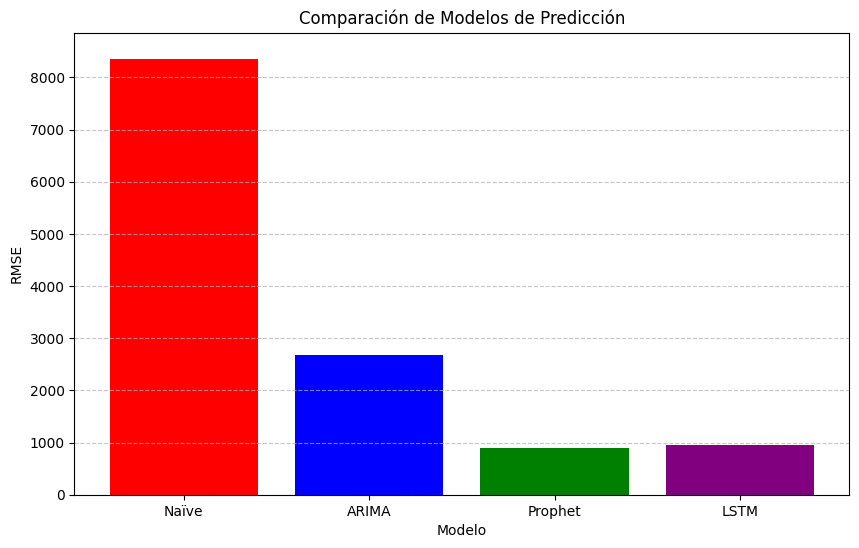

    Modelo         RMSE
0    Naïve  8356.449052
1    ARIMA  2684.555530
2  Prophet   891.807329
3     LSTM   948.245340


In [ ]:
# Comparación de modelos
rmse_results = pd.DataFrame({
    'Modelo': ['Naïve', 'ARIMA', 'Prophet', 'LSTM'],
    'RMSE': [rmse_naive, rmse_arima, rmse_prophet, rmse_lstm]
})

# Mostrar comparación en un gráfico
plt.figure(figsize=(10, 6))
plt.bar(rmse_results['Modelo'], rmse_results['RMSE'], color=['red', 'blue', 'green', 'purple'])
plt.xlabel('Modelo')
plt.ylabel('RMSE')
plt.title('Comparación de Modelos de Predicción')
plt.ylim(0, rmse_results['RMSE'].max() + 500)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(rmse_results)

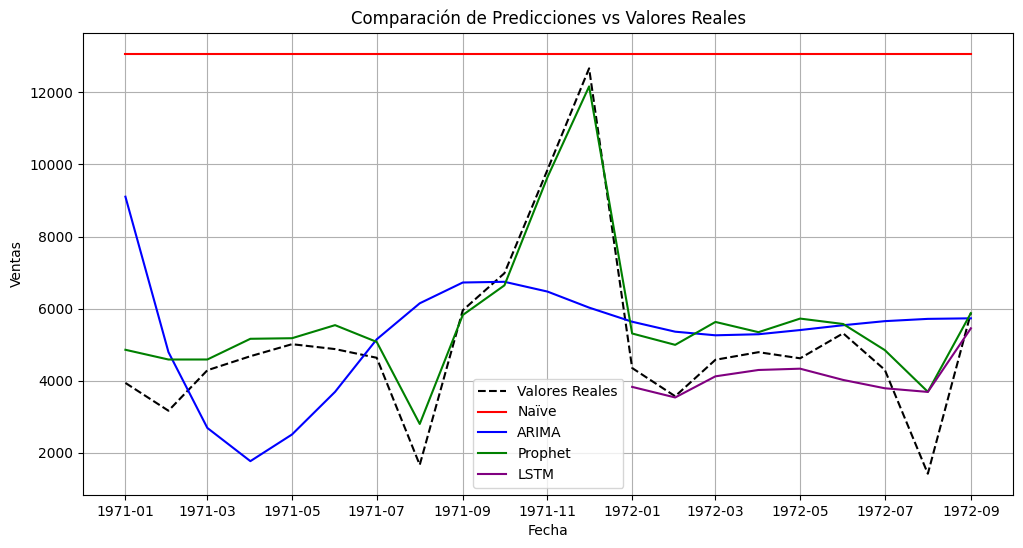

In [ ]:
# Gráfico de predicciones vs valores reales
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Sales'], label='Valores Reales', color='black', linestyle='dashed')
plt.plot(test.index, naive_forecast, label='Naïve', color='red')
plt.plot(test.index, arima_forecast, label='ARIMA', color='blue')
plt.plot(test.index, prophet_pred, label='Prophet', color='green')
plt.plot(test.index[time_steps:], lstm_forecast, label='LSTM', color='purple')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.title('Comparación de Predicciones vs Valores Reales')
plt.legend()
plt.grid(True)
plt.show()

| Análisis de Modelos de Predicción:
1.	Naïve es el peor modelo (RMSE > 8000) porque simplemente usa el último valor como predicción y no capta tendencias ni estacionalidad.
        Naïve (rojo): No varía, predice un único valor constante, lo que lo hace inútil en este caso.
2.	ARIMA mejora significativamente el error (~3000), pero sigue teniendo problemas para capturar fluctuaciones estacionales complejas.
        ARIMA (azul): Sigue la tendencia general, pero no modela bien los picos estacionales.
3.	Prophet es el modelo más preciso en esta prueba, con RMSE bajo (~900), ya que modela mejor la estacionalidad.
        Prophet (verde): Se ajusta mejor a los picos y caídas de la serie, lo que indica que captura bien la estacionalidad.
4.	LSTM muestra un buen desempeño (RMSE ~1270), aunque sigue ligeramente detrás de Prophet.
        LSTM (morado): Tiene un buen ajuste en general, pero tarda en estabilizarse debido a la naturaleza de las redes neuronales.
 
 Consideraciones Finales
LSTM, con más datos, puede mejorar su capacidad para detectar patrones complejos, pero requiere un mayor volumen de información para ser efectivo.
 Prophet tiene el menor RMSE (~900), lo que lo hace una excelente opción para negocios con datos moderados, ya que equilibra precisión y facilidad de uso.
